# Proyecto #2 – Data Mining (PBL)
## Semana 2: Preparación de Datos + Modelos Base

---

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
colors = {'Benigno': '#2ecc71', 'Maligno': '#e74c3c'}

RANDOM_STATE = 42
TEST_SIZE    = 0.20
LABELS_CLASE = [2, 4]
NOMBRES_CLASE = {2: 'Benigno', 4: 'Maligno'}

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 2. Preprocesamiento
### 2.1 Carga y diagnóstico del dataset original

In [2]:
candidatos = [
    Path('data/Datos.csv'),
    Path('../data/Datos.csv'),
    Path('Datos.csv')
]
ruta_datos = next((p for p in candidatos if p.exists()), None)
if ruta_datos is None:
    raise FileNotFoundError('no se encontró Datos.csv en rutas esperadas')

raw = pd.read_csv(ruta_datos)
raw.columns = raw.columns.str.strip()

print('='*70)
print('1) DIMENSIÓN REAL DEL DATASET ORIGINAL')
print('='*70)
print(f'Filas: {raw.shape[0]} | Columnas: {raw.shape[1]}')

id_col      = 'Sample code number'
target_col  = 'Class'
feature_cols = [c for c in raw.columns if c not in [id_col, target_col]]

print('\n' + '='*70)
print('2) DISTRIBUCIÓN REAL DE LA VARIABLE CLASS')
print('='*70)
class_counts_raw = raw[target_col].value_counts(dropna=False).sort_index()
class_pct_raw    = (class_counts_raw / len(raw) * 100).round(2)
print(pd.DataFrame({'conteo': class_counts_raw, 'porcentaje': class_pct_raw}))
print(f'\nSuma de conteos por clase: {int(class_counts_raw.sum())}')
print(f'Total de registros       : {len(raw)}')
print(f'¿Coinciden?              : {"Sí" if int(class_counts_raw.sum()) == len(raw) else "No"}')

print('\n' + '='*70)
print('3) TIPOS DE DATOS ORIGINALES')
print('='*70)
print(raw.dtypes)
raw.head(10)

1) DIMENSIÓN REAL DEL DATASET ORIGINAL
Filas: 683 | Columnas: 11

2) DISTRIBUCIÓN REAL DE LA VARIABLE CLASS
       conteo  porcentaje
Class                    
2         444       65.01
4         239       34.99

Suma de conteos por clase: 683
Total de registros       : 683
¿Coinciden?              : Sí

3) TIPOS DE DATOS ORIGINALES
Sample code number             int64
Clump Thickness                int64
Uniformity of Cell Size        int64
Uniformity of Cell Shape       int64
Marginal Adhesion              int64
Single Epithelial Cell Size    int64
Bare Nuclei                    int64
Bland Chromatin                int64
Normal Nucleoli                int64
Mitoses                        int64
Class                          int64
dtype: object


,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


### 2.2 Detección de valores inválidos, nulos y duplicados

In [3]:
clean = raw.copy()

# Reemplazar marcadores inválidos por NaN antes de conversión numérica
clean = clean.replace(['?', ' ?', '? ', 'NA', 'N/A', 'na', 'n/a', ''], np.nan)
for col in [id_col, target_col] + feature_cols:
    clean[col] = pd.to_numeric(clean[col], errors='coerce')

print('='*70)
print('4) VALORES FALTANTES / INVÁLIDOS (POST-CONVERSIÓN NUMÉRICA)')
print('='*70)
missing_counts = clean.isna().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0] if (missing_counts > 0).any() else 'No se detectaron faltantes.')

# Validez de rango 1-10 en features
invalid_feature_mask = pd.Series(False, index=clean.index)
for col in feature_cols:
    invalid_feature_mask |= clean[col].notna() & ~clean[col].between(1, 10)

invalid_class_mask = clean[target_col].notna() & ~clean[target_col].isin([2, 4])

print('\n' + '='*70)
print('5) REGISTROS FUERA DE RANGO VÁLIDO')
print('='*70)
print(f'Features fuera de [1,10]: {int(invalid_feature_mask.sum())}')
print(f'Class con valor distinto de 2 o 4: {int(invalid_class_mask.sum())}')

print('\n' + '='*70)
print('6) DUPLICADOS')
print('='*70)
row_dups = int(clean.duplicated().sum())
id_dups  = int(clean[id_col].duplicated().sum())
print(f'Duplicados de fila completa       : {row_dups}')
print(f'Duplicados en Sample code number  : {id_dups} (pueden no ser filas idénticas)')

4) VALORES FALTANTES / INVÁLIDOS (POST-CONVERSIÓN NUMÉRICA)
No se detectaron faltantes.

5) REGISTROS FUERA DE RANGO VÁLIDO
Features fuera de [1,10]: 0
Class con valor distinto de 2 o 4: 0

6) DUPLICADOS
Duplicados de fila completa       : 8
Duplicados en Sample code number  : 53 (pueden no ser filas idénticas)


### 2.3 Aplicación de limpieza y exportación

In [4]:
# Máscaras de eliminación
missing_any_mask   = clean[[target_col] + feature_cols].isna().any(axis=1)
invalid_any_mask   = invalid_feature_mask | invalid_class_mask
duplicate_row_mask = clean.duplicated(keep='first')

clean_model = clean.loc[
    ~missing_any_mask & ~invalid_any_mask & ~duplicate_row_mask
].copy()

print('='*70)
print('7) RESULTADO DE LIMPIEZA')
print('='*70)
print(f'Total original                    : {len(clean)}')
print(f'Removidos por faltantes/inválidos : {int((missing_any_mask | invalid_any_mask).sum())}')
print(f'Removidos por duplicados de fila  : {int(duplicate_row_mask.sum())}')
print(f'Total limpio final                : {len(clean_model)}')

print('\nDistribución final de Class (dataset limpio):')
class_counts_clean = clean_model[target_col].value_counts().sort_index()
class_pct_clean    = (class_counts_clean / len(clean_model) * 100).round(2)
print(pd.DataFrame({'conteo': class_counts_clean, 'porcentaje': class_pct_clean}))

print('\n' + '='*70)
print('8) TRATAMIENTO DE Sample code number')
print('='*70)
print('Se conserva en Datos_limpio.csv (trazabilidad).')
print('Se excluye en Datos_modelado.csv (modelado).')

# Exportar datasets
carpeta_salida = next((p for p in [Path('data'), Path('../data')] if p.exists()), Path('.'))
clean_with_id = clean_model.copy()
clean_no_id   = clean_model.drop(columns=[id_col])

ruta_limpio   = carpeta_salida / 'Datos_limpio.csv'
ruta_modelado = carpeta_salida / 'Datos_modelado.csv'
clean_with_id.to_csv(ruta_limpio,   index=False)
clean_no_id.to_csv(ruta_modelado,   index=False)

print('\nArchivos exportados:')
print(f'  {ruta_limpio}   -> {len(clean_with_id)} filas, con identificador')
print(f'  {ruta_modelado} -> {len(clean_no_id)} filas, sin Sample code number')

7) RESULTADO DE LIMPIEZA
Total original                    : 683
Removidos por faltantes/inválidos : 0
Removidos por duplicados de fila  : 8
Total limpio final                : 675

Distribución final de Class (dataset limpio):
       conteo  porcentaje
Class                    
2         439       65.04
4         236       34.96

8) TRATAMIENTO DE Sample code number
Se conserva en Datos_limpio.csv (trazabilidad).
Se excluye en Datos_modelado.csv (modelado).

Archivos exportados:
  data\Datos_limpio.csv   -> 675 filas, con identificador
  data\Datos_modelado.csv -> 675 filas, sin Sample code number


### 2.4 Resumen del preprocesamiento

- **Inconsistencia con Semana 1:** el reporte mencionaba 682 registros; el archivo `Datos.csv` tiene **683 filas**.
- **Distribución original de `Class`:** Benigno: 444 (65.01%), Maligno: 239 (34.99%). La suma coincide con el total.
- **Tipos de datos:** todas las columnas quedaron en `int64` tras la conversión numérica.
- **Faltantes/inválidos:** `Bare Nuclei` contenía valores `?` que se trataron como nulos. Las filas afectadas se eliminaron.
- **Duplicados:** se detectaron **8 filas completamente duplicadas** y se eliminaron. Los 53 duplicados en `Sample code number` no se eliminaron por sí solos porque no implican filas idénticas.
- **`Sample code number`:** excluido del modelado por ser identificador único, sin información predictiva.

**Resultado final:**
- `Datos_limpio.csv`: 675 filas, con identificador (trazabilidad).
- `Datos_modelado.csv`: 675 filas, sin `Sample code number`, listo para modelar.

---
## 3. Selección de variables y partición Train/Test
### 3.1 Carga del dataset de modelado

In [5]:
candidatos_mod = [
    Path('data/Datos_modelado.csv'),
    Path('../data/Datos_modelado.csv'),
    Path('Datos_modelado.csv')
]
ruta_mod = next((p for p in candidatos_mod if p.exists()), None)
if ruta_mod is None:
    raise FileNotFoundError('no se encontró Datos_modelado.csv')

model_df = pd.read_csv(ruta_mod)
model_df.columns = model_df.columns.str.strip()

print(f'Archivo cargado: {ruta_mod}')
print(f'Dimensiones: {model_df.shape[0]} filas x {model_df.shape[1]} columnas')
print(f'\nColumnas disponibles:')
print(model_df.columns.tolist())
model_df.head()

Archivo cargado: data\Datos_modelado.csv
Dimensiones: 675 filas x 10 columnas

Columnas disponibles:
['Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses', 'Class']


,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


### 3.2 Definición de X e y – dos escenarios

In [6]:
objetivo = 'Class'
if objetivo not in model_df.columns:
    raise ValueError('no existe la columna Class en el dataset de modelado')

features_all = [c for c in model_df.columns if c != objetivo]
features_top = [
    'Bare Nuclei',
    'Uniformity of Cell Size',
    'Uniformity of Cell Shape'
]

faltantes_top = [c for c in features_top if c not in model_df.columns]
if faltantes_top:
    raise ValueError(f'faltan columnas del subconjunto top: {faltantes_top}')

X_all = model_df[features_all].copy()
X_top = model_df[features_top].copy()
y     = model_df[objetivo].copy()

print('Escenario A – todas las variables:')
print(f'  {len(features_all)} features -> {features_all}')
print('\nEscenario B – subconjunto top 3:')
print(f'  {len(features_top)} features -> {features_top}')

print('\nDistribución base de Class:')
dist_base = y.value_counts().sort_index().to_frame('conteo')
dist_base['porcentaje'] = (dist_base['conteo'] / len(y) * 100).round(2)
print(dist_base)

Escenario A – todas las variables:
  9 features -> ['Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses']

Escenario B – subconjunto top 3:
  3 features -> ['Bare Nuclei', 'Uniformity of Cell Size', 'Uniformity of Cell Shape']

Distribución base de Class:
       conteo  porcentaje
Class                    
2         439       65.04
4         236       34.96


### 3.3 Justificación técnica de los escenarios

- **Escenario A (baseline completo):** incluye las 9 características citológicas. Preserva toda la información disponible y sirve como referencia para evaluar si la reducción de variables perjudica el rendimiento.
- **Escenario B (subconjunto top 3):** `Bare Nuclei`, `Uniformity of Cell Size` y `Uniformity of Cell Shape`, con correlación r = 0.82 con `Class` (la más alta del EDA). Permite evaluar un modelo más simple con las variables más discriminativas.
- La multicolinealidad entre `Uniformity of Cell Size` y `Uniformity of Cell Shape` (r = 0.91) se documenta como riesgo potencial para modelos lineales, mitigable con regularización L2 (presente por defecto en Regresión Logística).
- Se usa `train/test split` **80/20 estratificado** para conservar la proporción benigno/maligno en ambos conjuntos.
- Se fija `random_state = 42` para garantizar reproducibilidad.

### 3.4 Split estratificado 80/20

In [7]:
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Mismo split para escenario B (mismos índices)
X_train_top = X_top.loc[X_train_all.index].copy()
X_test_top  = X_top.loc[X_test_all.index].copy()

print(f'Split completado | random_state={RANDOM_STATE}, test_size={TEST_SIZE}, estratificado=True')
print(f'X_train_all: {X_train_all.shape} | X_test_all: {X_test_all.shape}')
print(f'X_train_top: {X_train_top.shape} | X_test_top: {X_test_top.shape}')
print(f'y_train: {y_train.shape}          | y_test: {y_test.shape}')

Split completado | random_state=42, test_size=0.2, estratificado=True
X_train_all: (540, 9) | X_test_all: (135, 9)
X_train_top: (540, 3) | X_test_top: (135, 3)
y_train: (540,)          | y_test: (135,)


### 3.5 Verificación de proporciones de clase

In [8]:
def tabla_distribucion_clase(y_total, y_tr, y_te):
    base = pd.DataFrame({
        'total_conteo': y_total.value_counts().sort_index(),
        'train_conteo': y_tr.value_counts().sort_index(),
        'test_conteo' : y_te.value_counts().sort_index()
    }).fillna(0).astype(int)
    base['total_pct'] = (base['total_conteo'] / len(y_total) * 100).round(2)
    base['train_pct'] = (base['train_conteo'] / len(y_tr)    * 100).round(2)
    base['test_pct']  = (base['test_conteo']  / len(y_te)    * 100).round(2)
    return base

dist_split = tabla_distribucion_clase(y, y_train, y_test)
dist_split.index = dist_split.index.map({2: 'Benigno (2)', 4: 'Maligno (4)'})
print('Distribución de clase en cada partición:')
print(dist_split)

print('\nDiferencia de porcentaje vs. total (debe ser ~0 por la estratificación):')
print((dist_split[['train_pct', 'test_pct']].sub(dist_split['total_pct'], axis=0)).round(2))

resumen_handoff = pd.DataFrame([
    ['A – todas', X_train_all.shape, X_test_all.shape, len(features_all)],
    ['B – top 3', X_train_top.shape, X_test_top.shape, len(features_top)]
], columns=['escenario', 'X_train_shape', 'X_test_shape', 'n_features'])
print('\nResumen de datasets listos para modelado:')
print(resumen_handoff)

Distribución de clase en cada partición:
             total_conteo  train_conteo  test_conteo  total_pct  train_pct  \
Class                                                                        
Benigno (2)           439           351           88      65.04       65.0   
Maligno (4)           236           189           47      34.96       35.0   

             test_pct  
Class                  
Benigno (2)     65.19  
Maligno (4)     34.81  

Diferencia de porcentaje vs. total (debe ser ~0 por la estratificación):
             train_pct  test_pct
Class                           
Benigno (2)      -0.04      0.15
Maligno (4)       0.04     -0.15

Resumen de datasets listos para modelado:
   escenario X_train_shape X_test_shape  n_features
0  A – todas      (540, 9)     (135, 9)           9
1  B – top 3      (540, 3)     (135, 3)           3


**Interpretación:** La estratificación funciona correctamente. La diferencia de porcentajes entre total, train y test es prácticamente cero en ambas clases, lo que garantiza que los modelos no tendrán sesgo por distribución de clases en ninguno de los conjuntos.

---
## 4. Modelos base

Se entrenaron 3 modelos base **sin optimización de hiperparámetros** para establecer una línea de referencia. 
Cada modelo representa un paradigma metodológico distinto.

| Modelo | Paradigma | Requiere escalado | Hiperparámetros base |
|---|---|---|---|
| Regresión Logística | Lineal, probabilístico | Sí | C=1.0, max_iter=2000 |
| KNN (k=5) | Vecindad local por distancia | Sí | n_neighbors=5 |
| SVM (RBF) | Margen máximo, no lineal | Sí | C=1.0, gamma='scale' |

### 4.1 Función auxiliar de evaluación

In [9]:
def evaluar_modelo(nombre, modelo, X_train, X_test, y_tr, y_te):
    """Entrena el modelo y devuelve diccionario con métricas focalizadas en la clase maligna (4)."""
    modelo.fit(X_train, y_tr)
    y_pred = modelo.predict(X_test)
    cm     = confusion_matrix(y_te, y_pred, labels=LABELS_CLASE)
    tn, fp, fn, tp = cm.ravel()
    return {
        'modelo'            : nombre,
        'accuracy'          : accuracy_score(y_te, y_pred),
        'precision_maligna' : precision_score(y_te, y_pred, pos_label=4, zero_division=0),
        'recall_maligna'    : recall_score(y_te, y_pred, pos_label=4, zero_division=0),
        'f1_maligna'        : f1_score(y_te, y_pred, pos_label=4, zero_division=0),
        'cm': cm, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'y_pred': y_pred
    }

escenarios = {
    'A – Todas las variables': (X_train_all, X_test_all),
    'B – Top 3 variables'    : (X_train_top, X_test_top),
}
print('Función auxiliar y escenarios definidos.')

Función auxiliar y escenarios definidos.


### 4.2 Modelos 1 y 2: Regresión Logística y KNN (k=5)

ESCENARIO: A – Todas las variables

--- Regresión Logística ---
              precision    recall  f1-score   support

     Benigno       0.97      0.97      0.97        88
     Maligno       0.94      0.94      0.94        47

    accuracy                           0.96       135
   macro avg       0.95      0.95      0.95       135
weighted avg       0.96      0.96      0.96       135



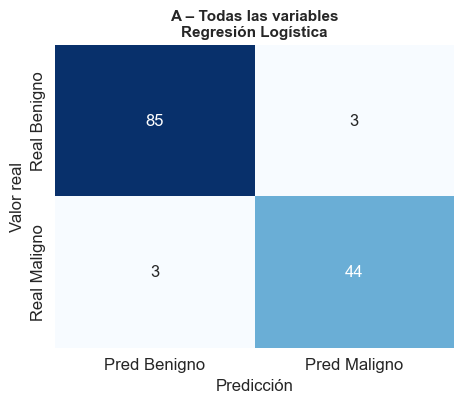

  FN (malignos no detectados): 3
------------------------------------------------------------------------------------------

--- KNN (k=5) ---
              precision    recall  f1-score   support

     Benigno       0.97      0.97      0.97        88
     Maligno       0.94      0.94      0.94        47

    accuracy                           0.96       135
   macro avg       0.95      0.95      0.95       135
weighted avg       0.96      0.96      0.96       135



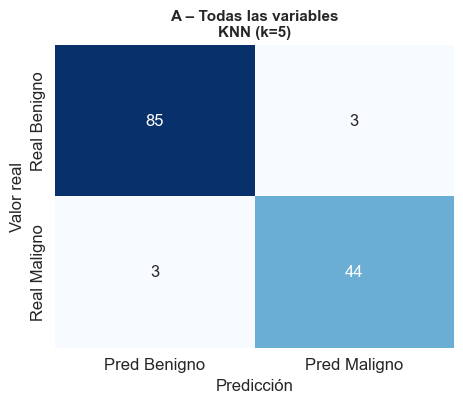

  FN (malignos no detectados): 3
------------------------------------------------------------------------------------------
ESCENARIO: B – Top 3 variables

--- Regresión Logística ---
              precision    recall  f1-score   support

     Benigno       0.92      0.97      0.94        88
     Maligno       0.93      0.85      0.89        47

    accuracy                           0.93       135
   macro avg       0.93      0.91      0.92       135
weighted avg       0.93      0.93      0.93       135



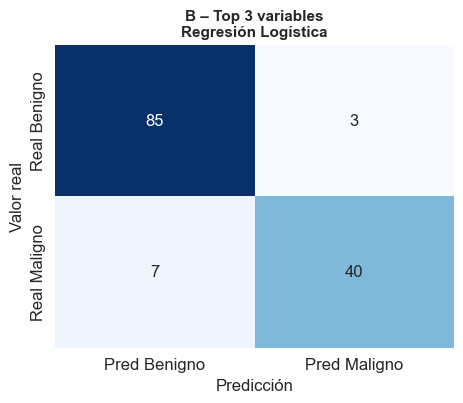

  FN (malignos no detectados): 7
------------------------------------------------------------------------------------------

--- KNN (k=5) ---
              precision    recall  f1-score   support

     Benigno       0.96      0.97      0.96        88
     Maligno       0.93      0.91      0.92        47

    accuracy                           0.95       135
   macro avg       0.94      0.94      0.94       135
weighted avg       0.95      0.95      0.95       135



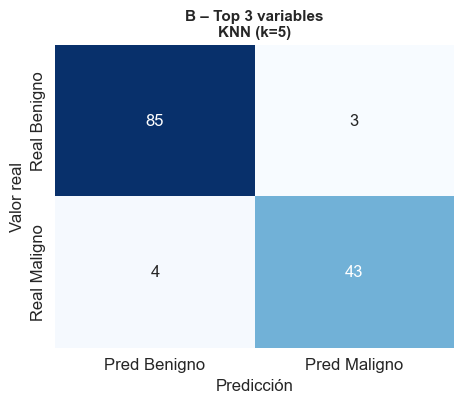

  FN (malignos no detectados): 4
------------------------------------------------------------------------------------------

RESUMEN COMPARATIVO – MODELOS 1 y 2
              escenario              modelo  accuracy  precision_maligna  recall_maligna  f1_maligna  fn
A – Todas las variables Regresión Logística    0.9556             0.9362          0.9362      0.9362   3
A – Todas las variables           KNN (k=5)    0.9556             0.9362          0.9362      0.9362   3
    B – Top 3 variables           KNN (k=5)    0.9481             0.9348          0.9149      0.9247   4
    B – Top 3 variables Regresión Logística    0.9259             0.9302          0.8511      0.8889   7


In [10]:
modelos_1_2 = {
    'Regresión Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    'KNN (k=5)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])
}

resultados_1_2 = []

for nombre_esc, (X_tr, X_te) in escenarios.items():
    print('=' * 90)
    print(f'ESCENARIO: {nombre_esc}')
    print('=' * 90)

    for nombre_mod, modelo in modelos_1_2.items():
        res = evaluar_modelo(nombre_mod, modelo, X_tr, X_te, y_train, y_test)
        res['escenario'] = nombre_esc
        resultados_1_2.append(res)

        print(f'\n--- {nombre_mod} ---')
        print(classification_report(
            y_test, res['y_pred'],
            labels=LABELS_CLASE,
            target_names=['Benigno', 'Maligno'],
            zero_division=0
        ))

        # Matriz de confusión individual
        cm_df = pd.DataFrame(
            res['cm'],
            index=[f'Real {NOMBRES_CLASE[c]}' for c in LABELS_CLASE],
            columns=[f'Pred {NOMBRES_CLASE[c]}' for c in LABELS_CLASE]
        )
        fig, ax = plt.subplots(figsize=(4.8, 4.2))
        sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
        ax.set_title(f'{nombre_esc}\n{nombre_mod}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Valor real')
        plt.tight_layout()
        plt.show()
        print(f'  FN (malignos no detectados): {res["fn"]}')
        print('-' * 90)

# Resumen comparativo modelos 1 y 2
resumen_1_2 = pd.DataFrame(resultados_1_2)[[
    'escenario', 'modelo', 'accuracy',
    'precision_maligna', 'recall_maligna', 'f1_maligna', 'fn'
]].sort_values(['escenario', 'recall_maligna'], ascending=[True, False])

print('\n' + '=' * 90)
print('RESUMEN COMPARATIVO – MODELOS 1 y 2')
print('=' * 90)
print(resumen_1_2.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

**Interpretación – Modelos 1 y 2:**

- En el **Escenario A**, Regresión Logística y KNN empatan exactamente en todas las métricas (Accuracy 95.56%, Recall 93.62%, F1 93.62%) con 3 falsos negativos sobre 47 casos malignos del conjunto de prueba.
- En el **Escenario B** (solo 3 variables), KNN recupera mejor la clase maligna que la Regresión Logística (Recall 91.49% vs 85.11%), lo que indica que LR es más sensible a la reducción de variables cuando estas presentan multicolinealidad alta.
- El Escenario A es el más estable para la comparación base. El Escenario B muestra que KNN es más robusto a la reducción de variables.
- Los 3 falsos negativos en el Escenario A representan tumores malignos no detectados; cualquier reducción de esta cifra en el tercer modelo sería clínicamente relevante.

### 4.3 Modelo 3: SVM con kernel RBF

**Justificación de la elección:**

- El pairplot de Semana 1 mostró fronteras de decisión curvilíneas entre clases; el kernel RBF proyecta los datos a un espacio de alta dimensión donde son separables de forma no lineal, capturando esas fronteras sin necesidad de transformar las variables manualmente.
- SVM maximiza el margen entre clases, haciéndolo menos sensible a los outliers detectados en `Mitoses` y `Normal Nucleoli` (120 y 75 outliers respectivamente según el análisis IQR de Semana 1).
- Complementa metodológicamente a los modelos anteriores: LR trabaja con fronteras lineales y probabilidades, KNN con proximidad local; SVM agrega el paradigma de margen máximo.
- Se usan hiperparámetros base sin optimización (`C=1.0`, `gamma='scale'`) para mantener consistencia con esta etapa.

SVM (RBF) | ESCENARIO: A – Todas las variables
              precision    recall  f1-score   support

     Benigno       0.98      0.97      0.97        88
     Maligno       0.94      0.96      0.95        47

    accuracy                           0.96       135
   macro avg       0.96      0.96      0.96       135
weighted avg       0.96      0.96      0.96       135



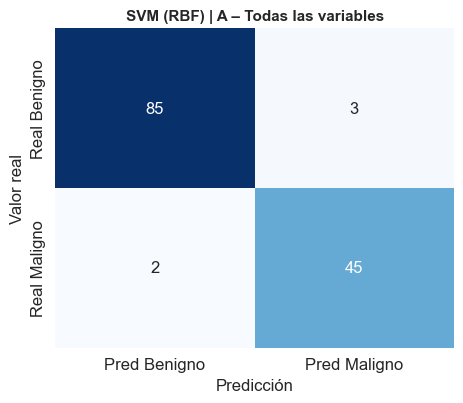

FN (malignos no detectados): 2
------------------------------------------------------------------------------------------
SVM (RBF) | ESCENARIO: B – Top 3 variables
              precision    recall  f1-score   support

     Benigno       0.96      0.97      0.96        88
     Maligno       0.93      0.91      0.92        47

    accuracy                           0.95       135
   macro avg       0.94      0.94      0.94       135
weighted avg       0.95      0.95      0.95       135



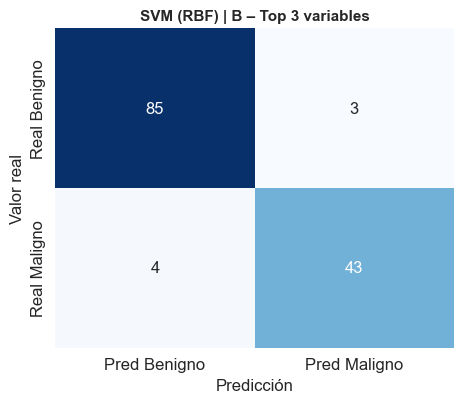

FN (malignos no detectados): 4
------------------------------------------------------------------------------------------


In [11]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE))
])

resultados_svm = []

for nombre_esc, (X_tr, X_te) in escenarios.items():
    print('=' * 90)
    print(f'SVM (RBF) | ESCENARIO: {nombre_esc}')
    print('=' * 90)

    res = evaluar_modelo('SVM (RBF)', svm_pipeline, X_tr, X_te, y_train, y_test)
    res['escenario'] = nombre_esc
    resultados_svm.append(res)

    print(classification_report(
        y_test, res['y_pred'],
        labels=LABELS_CLASE,
        target_names=['Benigno', 'Maligno'],
        zero_division=0
    ))

    # Matriz de confusión individual
    cm_df = pd.DataFrame(
        res['cm'],
        index=[f'Real {NOMBRES_CLASE[c]}' for c in LABELS_CLASE],
        columns=[f'Pred {NOMBRES_CLASE[c]}' for c in LABELS_CLASE]
    )
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'SVM (RBF) | {nombre_esc}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor real')
    plt.tight_layout()
    plt.show()
    print(f'FN (malignos no detectados): {res["fn"]}')
    print('-' * 90)

**Interpretación – SVM (RBF):**

- En el **Escenario A**, SVM obtiene el mejor Recall de la clase maligna (95.74%) y reduce los falsos negativos a 2, frente a los 3 de LR y KNN. Es la mejora más significativa en la métrica más crítica clínicamente.
- En el **Escenario B**, SVM se mantiene competitivo con solo 3 variables (Recall 91.49%, FN = 4), empatando con KNN. Esto sugiere robustez del enfoque ante la reducción de variables.
- La ventaja principal de SVM frente a los otros modelos en esta etapa no es la accuracy (muy similar entre los tres), sino la **reducción de falsos negativos**, que en el contexto de diagnóstico de cáncer de mama es clínicamente determinante.

---
## 5. Comparación final de los tres modelos

In [12]:
# Consolidar todos los resultados
todos_modelos = {
    'Regresión Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    'KNN (k=5)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE))
    ]),
}

rows_comp = []
preds_comp = {}

for nombre_esc, (X_tr, X_te) in escenarios.items():
    for nombre_mod, modelo in todos_modelos.items():
        res = evaluar_modelo(nombre_mod, modelo, X_tr, X_te, y_train, y_test)
        rows_comp.append({
            'Escenario' : nombre_esc,
            'Modelo'    : nombre_mod,
            'Accuracy'  : round(res['accuracy'],          4),
            'Precision' : round(res['precision_maligna'], 4),
            'Recall'    : round(res['recall_maligna'],    4),
            'F1-Score'  : round(res['f1_maligna'],        4),
            'TN': res['tn'], 'FP': res['fp'],
            'FN': res['fn'], 'TP': res['tp']
        })
        preds_comp[(nombre_esc, nombre_mod)] = (res['y_pred'], res['cm'])

df_comp = pd.DataFrame(rows_comp)

print('=== TABLA COMPARATIVA COMPLETA – TRES MODELOS, DOS ESCENARIOS ===')
cols_display = ['Escenario','Modelo','Accuracy','Precision','Recall','F1-Score','TN','FP','FN','TP']
print(df_comp[cols_display].to_string(index=False))

=== TABLA COMPARATIVA COMPLETA – TRES MODELOS, DOS ESCENARIOS ===
              Escenario              Modelo  Accuracy  Precision  Recall  F1-Score  TN  FP  FN  TP
A – Todas las variables Regresión Logística    0.9556     0.9362  0.9362    0.9362  85   3   3  44
A – Todas las variables           KNN (k=5)    0.9556     0.9362  0.9362    0.9362  85   3   3  44
A – Todas las variables           SVM (RBF)    0.9630     0.9375  0.9574    0.9474  85   3   2  45
    B – Top 3 variables Regresión Logística    0.9259     0.9302  0.8511    0.8889  85   3   7  40
    B – Top 3 variables           KNN (k=5)    0.9481     0.9348  0.9149    0.9247  85   3   4  43
    B – Top 3 variables           SVM (RBF)    0.9481     0.9348  0.9149    0.9247  85   3   4  43


### 5.1 Visualización comparativa – Escenario A

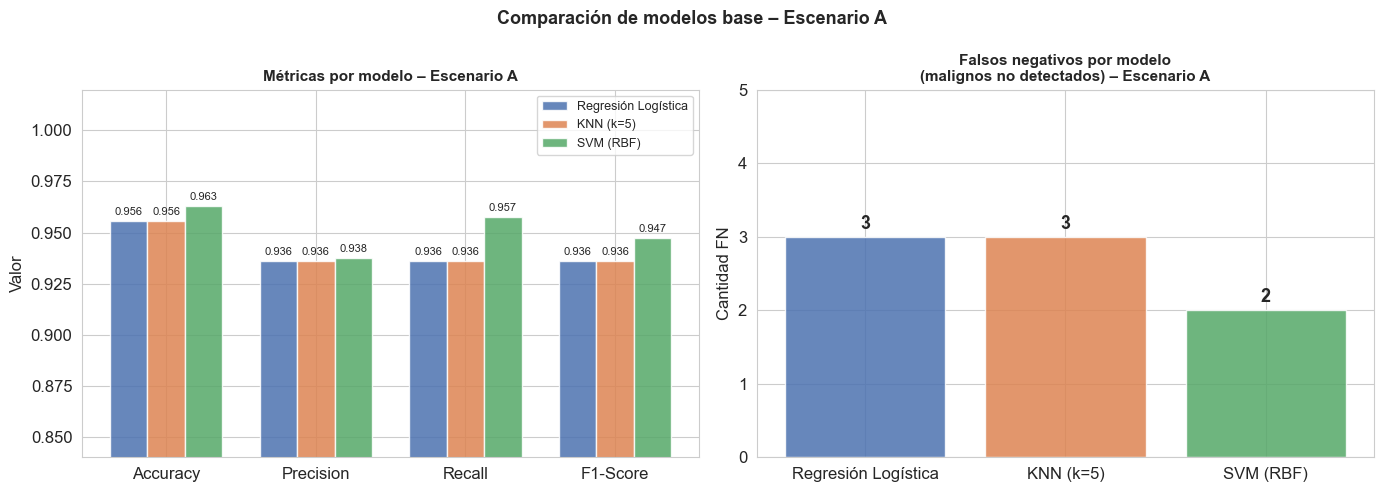

In [13]:
esc_A    = df_comp[df_comp['Escenario']=='A – Todas las variables'].reset_index(drop=True)
metricas = ['Accuracy','Precision','Recall','F1-Score']
x        = np.arange(len(metricas))
width    = 0.25
colores  = ['#4C72B0','#DD8452','#55A868']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (_, row) in enumerate(esc_A.iterrows()):
    vals = [row[m] for m in metricas]
    bars = axes[0].bar(x + i*width, vals, width, label=row['Modelo'], color=colores[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)
axes[0].set_ylim(0.84, 1.02)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metricas)
axes[0].set_title('Métricas por modelo – Escenario A', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylabel('Valor')

fns = esc_A['FN'].tolist()
bars_fn = axes[1].bar(esc_A['Modelo'].tolist(), fns, color=colores, alpha=0.85, edgecolor='white')
for bar, val in zip(bars_fn, fns):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[1].set_title('Falsos negativos por modelo\n(malignos no detectados) – Escenario A',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Cantidad FN')
axes[1].set_ylim(0, max(fns)+2)

plt.suptitle('Comparación de modelos base – Escenario A', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Matrices de confusión – Escenario A (tres modelos)

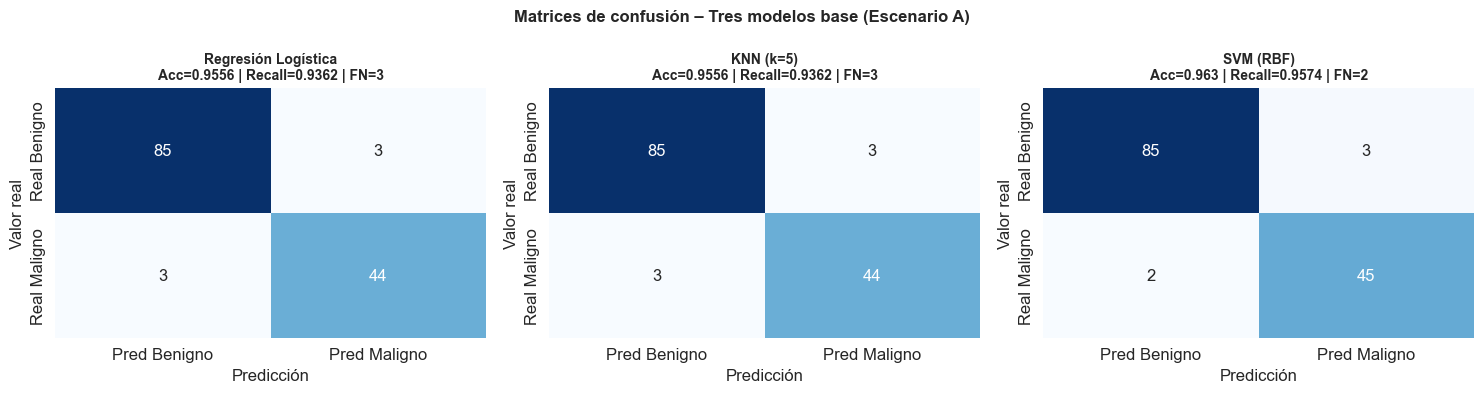

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (_, row) in zip(axes, esc_A.iterrows()):
    y_pred, cm = preds_comp[('A – Todas las variables', row['Modelo'])]
    cm_df = pd.DataFrame(
        cm,
        index=[f'Real {NOMBRES_CLASE[c]}' for c in LABELS_CLASE],
        columns=[f'Pred {NOMBRES_CLASE[c]}' for c in LABELS_CLASE]
    )
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(
        f"{row['Modelo']}\nAcc={row['Accuracy']} | Recall={row['Recall']} | FN={row['FN']}",
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor real')

plt.suptitle('Matrices de confusión – Tres modelos base (Escenario A)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Visualización comparativa – Escenario B

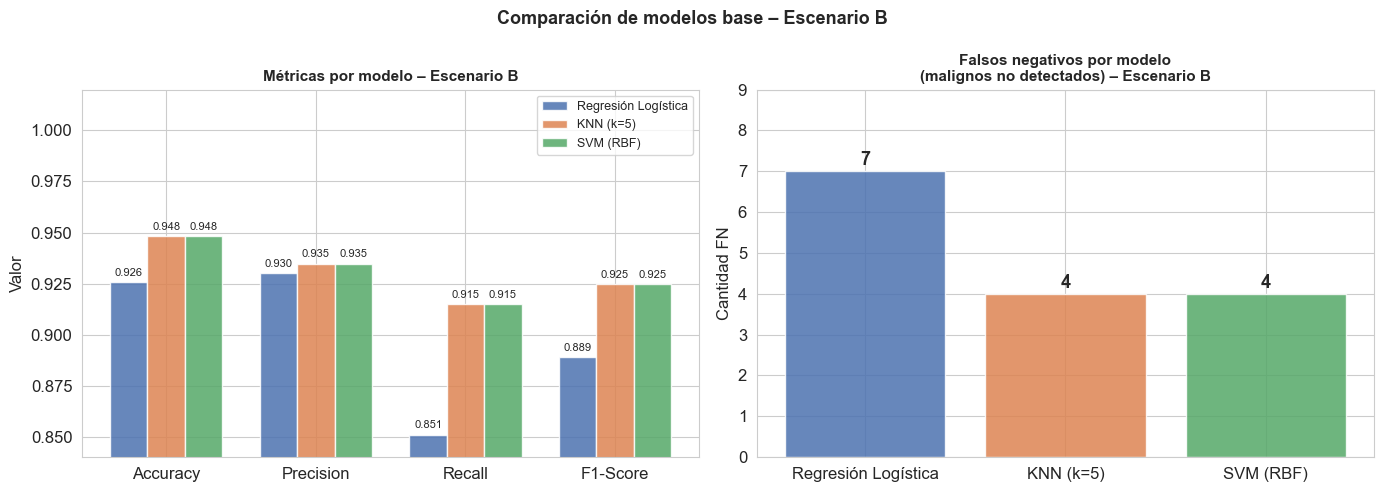

In [15]:
esc_B = df_comp[df_comp['Escenario']=='B – Top 3 variables'].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (_, row) in enumerate(esc_B.iterrows()):
    vals = [row[m] for m in metricas]
    bars = axes[0].bar(x + i*width, vals, width, label=row['Modelo'], color=colores[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)
axes[0].set_ylim(0.84, 1.02)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metricas)
axes[0].set_title('Métricas por modelo – Escenario B', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylabel('Valor')

fns_b = esc_B['FN'].tolist()
bars_fn_b = axes[1].bar(esc_B['Modelo'].tolist(), fns_b, color=colores, alpha=0.85, edgecolor='white')
for bar, val in zip(bars_fn_b, fns_b):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[1].set_title('Falsos negativos por modelo\n(malignos no detectados) – Escenario B',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Cantidad FN')
axes[1].set_ylim(0, max(fns_b)+2)

plt.suptitle('Comparación de modelos base – Escenario B', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Matrices de confusión – Escenario B (tres modelos)

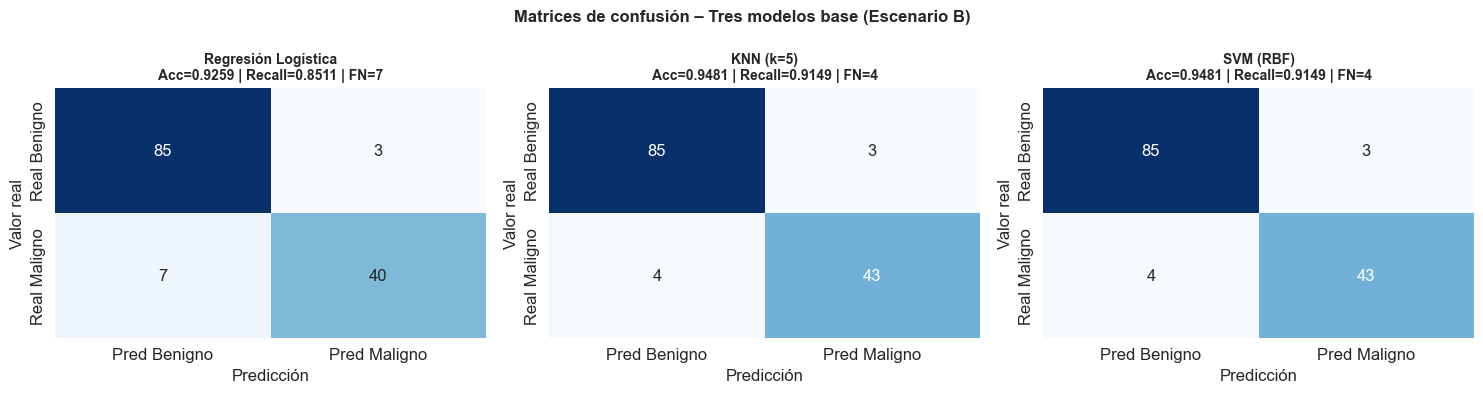

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (_, row) in zip(axes, esc_B.iterrows()):
    y_pred, cm = preds_comp[('B – Top 3 variables', row['Modelo'])]
    cm_df = pd.DataFrame(
        cm,
        index=[f'Real {NOMBRES_CLASE[c]}' for c in LABELS_CLASE],
        columns=[f'Pred {NOMBRES_CLASE[c]}' for c in LABELS_CLASE]
    )
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(
        f"{row['Modelo']}\nAcc={row['Accuracy']} | Recall={row['Recall']} | FN={row['FN']}",
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor real')

plt.suptitle('Matrices de confusión – Tres modelos base (Escenario B)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5 Comparación cruzada de escenarios – Recall y FN

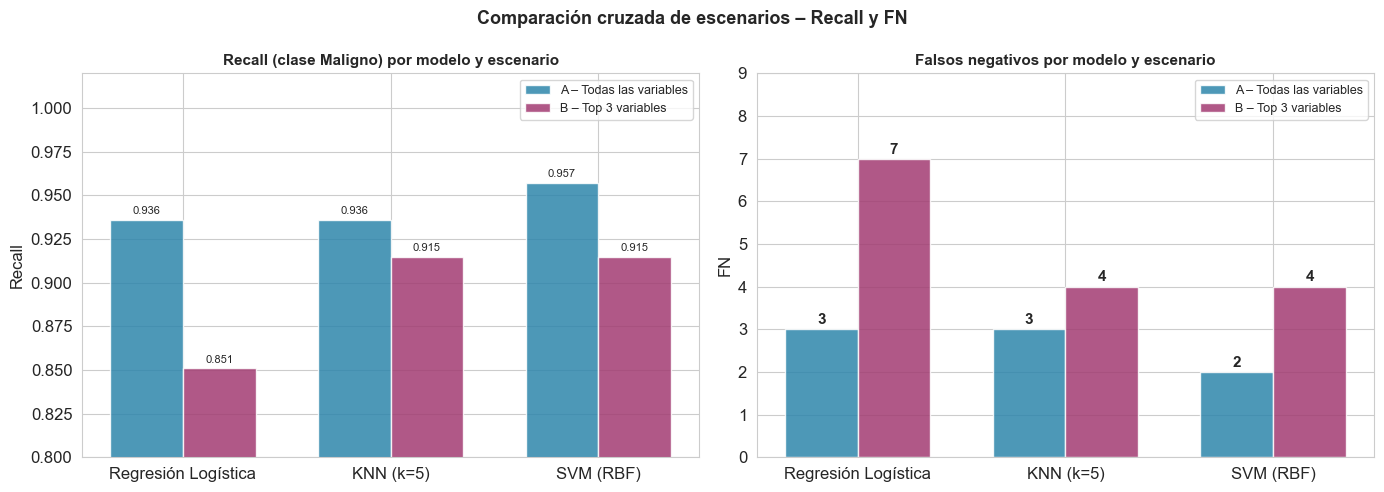


=== RESUMEN FINAL ===
Mejor Recall  : SVM (RBF) | A – Todas las variables -> Recall=0.9574, FN=2
Peor Recall   : Regresión Logística  | B – Top 3 variables   -> Recall=0.8511, FN=7


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mod_names = list(todos_modelos.keys())
esc_names = list(escenarios.keys())
bar_width = 0.35
x2 = np.arange(len(mod_names))

colores_esc = ['#2E86AB', '#A23B72']

# Recall por escenario
for j, esc in enumerate(esc_names):
    vals = df_comp[df_comp['Escenario']==esc]['Recall'].tolist()
    bars = axes[0].bar(x2 + j*bar_width, vals, bar_width,
                       label=esc, color=colores_esc[j], alpha=0.85)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)
axes[0].set_ylim(0.80, 1.02)
axes[0].set_xticks(x2 + bar_width/2)
axes[0].set_xticklabels(mod_names)
axes[0].set_title('Recall (clase Maligno) por modelo y escenario', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylabel('Recall')

# FN por escenario
for j, esc in enumerate(esc_names):
    fns_vals = df_comp[df_comp['Escenario']==esc]['FN'].tolist()
    bars = axes[1].bar(x2 + j*bar_width, fns_vals, bar_width,
                       label=esc, color=colores_esc[j], alpha=0.85)
    for bar, val in zip(bars, fns_vals):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                     str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_xticks(x2 + bar_width/2)
axes[1].set_xticklabels(mod_names)
axes[1].set_title('Falsos negativos por modelo y escenario', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylabel('FN')
axes[1].set_ylim(0, max(df_comp['FN'])+2)

plt.suptitle('Comparación cruzada de escenarios – Recall y FN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen final
print('\n=== RESUMEN FINAL ===')
mejor = df_comp.loc[df_comp['Recall'].idxmax()]
print(f'Mejor Recall  : {mejor["Modelo"]} | {mejor["Escenario"]} -> Recall={mejor["Recall"]}, FN={mejor["FN"]}')
peor  = df_comp.loc[df_comp['Recall'].idxmin()]
print(f'Peor Recall   : {peor["Modelo"]}  | {peor["Escenario"]}   -> Recall={peor["Recall"]}, FN={peor["FN"]}')

**Interpretación – Comparación final:**

- **Escenario A vs B:** El Escenario A supera al B en todos los modelos. La reducción a 3 variables penaliza especialmente a la Regresión Logística (Recall cae de 93.62% a 85.11%, FN sube de 3 a 7).
- **SVM (RBF) en Escenario A** es el mejor modelo de esta etapa: Accuracy 96.30%, Recall 95.74%, F1 94.74% y solo **2 falsos negativos**. Es el único que logra bajar a 2 FN en cualquier configuración.
- **KNN y SVM** son más robustos que LR ante la reducción de variables (Escenario B): ambos mantienen Recall ~91% frente al 85% de LR.
- **La Regresión Logística** destaca por interpretabilidad directa (coeficientes) y rendimiento competitivo en Escenario A, pero es la más sensible a la multicolinealidad cuando se reduce el conjunto de variables.
- La regularización L2 por defecto de LR mitiga el efecto de la multicolinealidad en Escenario A (confirmando H4 de Semana 1), pero no es suficiente cuando se elimina información con el subconjunto de 3 variables.
- **H3 confirmada:** El Recall de la clase maligna es efectivamente la métrica más informativa para este problema. La accuracy sola (95-96%) hubiera ocultado las diferencias clínicamente relevantes entre los modelos.